# 1. Preparação

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

data = pd.read_csv("bigpaired_weight.csv")

before = data.loc[data["group"]=="before","weight"].values
after  = data.loc[data["group"]=="after","weight"].values

d = before - after

# 2. Teste de normalidade (Shapiro)

In [2]:
print(stats.shapiro(d))

ShapiroResult(statistic=np.float64(0.9880209795043112), pvalue=np.float64(0.5097553517438596))


# 3. Teste F (homogeneidade de variância)

In [3]:
var_before = np.var(before, ddof=1)
var_after  = np.var(after, ddof=1)

F = var_before/var_after

df1 = len(before)-1
df2 = len(after)-1

print("F =",F)

F = 0.9249728108322272


# 4. Gráfico da distribuição F

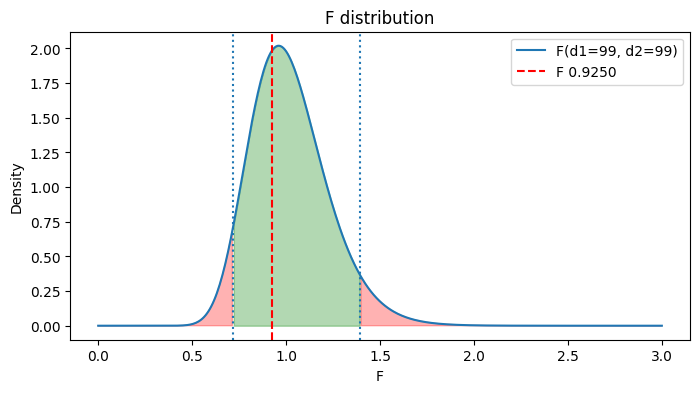

In [4]:
x = np.linspace(0,3,400)

y = stats.f.pdf(x, df1, df2)

Fcrit_high = stats.f.ppf(0.95, df1, df2)
Fcrit_low = 1/Fcrit_high

plt.figure(figsize=(8,4))
plt.plot(x,y, label=f'F(d1={df1}, d2={df2})')

plt.axvline(F,color="red",linestyle="--", label=f"F {F:.4f}")
plt.axvline(Fcrit_high,linestyle=":")
plt.axvline(Fcrit_low,linestyle=":")

plt.fill_between(x, y, where=((x < Fcrit_low) | (x > Fcrit_high)), alpha= 0.3, color='red')
plt.fill_between(x, y, where=((x >= Fcrit_low) & (x <= Fcrit_high) ), alpha=0.3, color='green')


plt.title("F distribution")
plt.xlabel("F")
plt.ylabel("Density")
plt.legend()

plt.show()

# 5. Paired Z-test

In [5]:
mean_d = np.mean(d)
sd_d = np.std(d,ddof=1)
n = len(d)

z = mean_d/(sd_d/np.sqrt(n))

p = 2*(1-stats.norm.cdf(abs(z)))

print("Z =",z)
print("p =",p)

Z = -109.624012997932
p = 0.0


# 6. Gráfico da distribuição Z

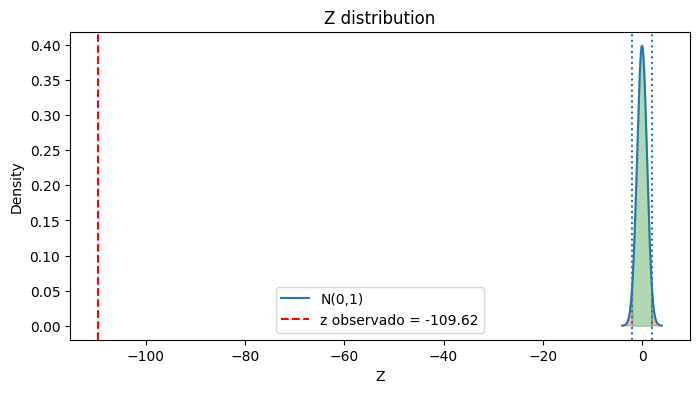

In [6]:
x = np.linspace(-4,4,400)
y = stats.norm.pdf(x)

zcrit = stats.norm.ppf(0.975)

plt.figure(figsize=(8,4))
plt.plot(x,y, label="N(0,1)")

plt.axvline(z,color="red",linestyle="--", label=f"z observado = {z:.2f}")
plt.axvline(zcrit,linestyle=":")
plt.axvline(-zcrit,linestyle=":")

plt.fill_between(x, y, where=((x < -zcrit) | (x > zcrit)), alpha=0.3, color='red')
plt.fill_between(x, y, where=((x >= -zcrit) & (x <= zcrit) ), alpha=0.3, color='green')

plt.title("Z distribution")
plt.xlabel("Z")
plt.ylabel("Density")
plt.legend()


plt.show()

# 7. Paired t-test

In [11]:
# Carregar duas amostras pareadas pequenas
data = pd.read_csv("paired_weight.csv")

before = data.loc[data["group"]=="before","weight"].values
after  = data.loc[data["group"]=="after","weight"].values

d = before - after

n = len(d)

In [12]:
t,p = stats.ttest_rel(before,after)

print("t =",t)
print("p =",p)

t = -20.8831333638503
p = 6.200298210361311e-09


# 8. Gráfico da distribuição t

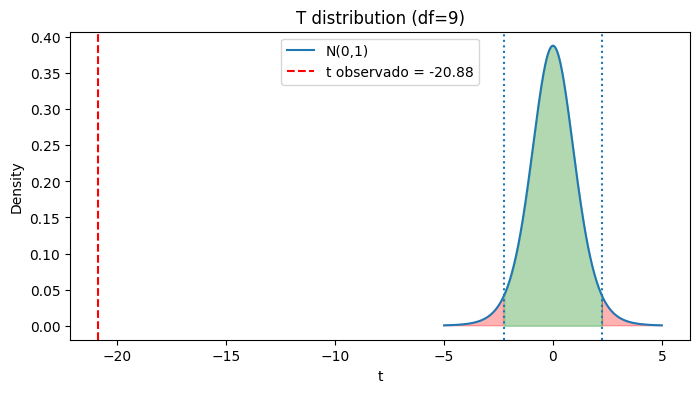

In [13]:
df = n-1

x = np.linspace(-5,5,400)
y = stats.t.pdf(x,df)

tcrit = stats.t.ppf(0.975,df)

plt.figure(figsize=(8,4))
plt.plot(x,y, label="N(0,1)")

plt.axvline(t,color="red",linestyle="--", label=f"t observado = {t:.2f}")
plt.axvline(tcrit,linestyle=":")
plt.axvline(-tcrit,linestyle=":")

plt.fill_between(x,y,where=((x < -tcrit) | (x > tcrit)), alpha=0.3, color='red')
plt.fill_between(x, y, where=((x >= -tcrit) & (x <= tcrit) ), alpha=0.3, color='green')

plt.title(f"T distribution (df={df})")
plt.xlabel("t")
plt.ylabel("Density")
plt.legend()

plt.show()

# Versão sem gráficos

# 1. Paired Z test

In [ ]:
import numpy as np
import pandas as pd
from scipy import stats

# carregar dados
bigpaired_weight = pd.read_csv("bigpaired_weight.csv")

# separar grupos
before = bigpaired_weight.loc[bigpaired_weight["group"]=="before","weight"].values
after  = bigpaired_weight.loc[bigpaired_weight["group"]=="after","weight"].values

# diferença pareada
d1 = before - after

# -----------------------------
# Teste de normalidade Shapiro
# -----------------------------
shapiro_test = stats.shapiro(d1)
print(shapiro_test)

# -----------------------------
# Teste F para variâncias
# -----------------------------
var_before = np.var(before, ddof=1)
var_after  = np.var(after, ddof=1)

F = var_before / var_after
df1 = len(before)-1
df2 = len(after)-1

p_value_f = 2 * min(
    stats.f.cdf(F, df1, df2),
    1 - stats.f.cdf(F, df1, df2)
)

print("F =", F)
print("p-value =", p_value_f)

# -----------------------------
# Paired Z test
# -----------------------------
mean_d = np.mean(d1)
std_d = np.std(d1, ddof=1)
n = len(d1)

z = mean_d / (std_d / np.sqrt(n))
p_value = 2 * (1 - stats.norm.cdf(abs(z)))

print("Z =", z)
print("p-value =", p_value)

# intervalo de confiança
alpha = 0.05
z_crit = stats.norm.ppf(1-alpha/2)

ci_low = mean_d - z_crit*(std_d/np.sqrt(n))
ci_high = mean_d + z_crit*(std_d/np.sqrt(n))

print("IC 95% =", ci_low, ci_high)

# 2 Paired t Test

In [ ]:
import numpy as np
import pandas as pd
from scipy import stats

paired_weight = pd.read_csv("paired_weight.csv")

before = paired_weight.loc[paired_weight["group"]=="before","weight"].values
after  = paired_weight.loc[paired_weight["group"]=="after","weight"].values

# diferença
d = before - after

# -----------------------------
# normalidade
# -----------------------------
print(stats.shapiro(d))

# -----------------------------
# F test variâncias
# -----------------------------
var_before = np.var(before, ddof=1)
var_after  = np.var(after, ddof=1)

F = var_before/var_after
df1 = len(before)-1
df2 = len(after)-1

p_value_f = 2*min(stats.f.cdf(F,df1,df2),
                  1-stats.f.cdf(F,df1,df2))

print("F =",F,"p=",p_value_f)

# -----------------------------
# Paired t-test
# -----------------------------
t_stat, p_value = stats.ttest_rel(before, after)

print("t =", t_stat)
print("p =", p_value)

# intervalo de confiança
mean_d = np.mean(d)
std_d = np.std(d, ddof=1)
n = len(d)

t_crit = stats.t.ppf(0.975, n-1)

ci_low = mean_d - t_crit*(std_d/np.sqrt(n))
ci_high = mean_d + t_crit*(std_d/np.sqrt(n))

print("IC95%:", ci_low, ci_high)